In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib

In [2]:
df = pd.read_csv("google-10000-english.csv", header=None, names=["word"])

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.isnull().sum())

  word
0  the
1   of
2  and
3   to
4    a
(10000, 1)
Index(['word'], dtype='object')
word    1
dtype: int64


In [4]:
df['word'] = df['word'].astype(str).str.lower().str.strip()
df = df[df['word'] != ""]
df.drop_duplicates(inplace=True)

In [5]:
print("Total unique words:", len(df))
print(df.head(10))

Total unique words: 10000
   word
0   the
1    of
2   and
3    to
4     a
5    in
6   for
7    is
8    on
9  that


In [6]:
df['length'] = df['word'].apply(len)

In [7]:
print("Average word length:", df['length'].mean())
print("Shortest word length:", df['length'].min())
print("Longest word length:", df['length'].max())

Average word length: 6.5887
Shortest word length: 1
Longest word length: 18


In [8]:
df['first_letter'] = df['word'].str[0]
print(df['first_letter'].value_counts().head(10))

first_letter
c    1015
s    1007
p     792
a     719
r     582
d     558
m     557
t     549
b     536
e     465
Name: count, dtype: int64


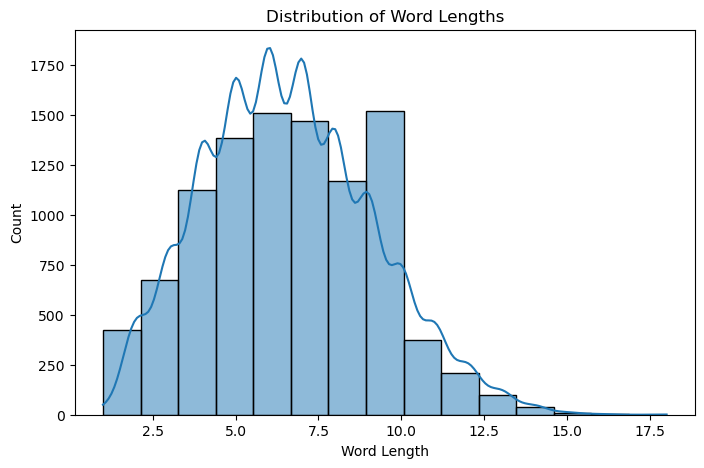

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['length'], bins=15, kde=True)
plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.show()


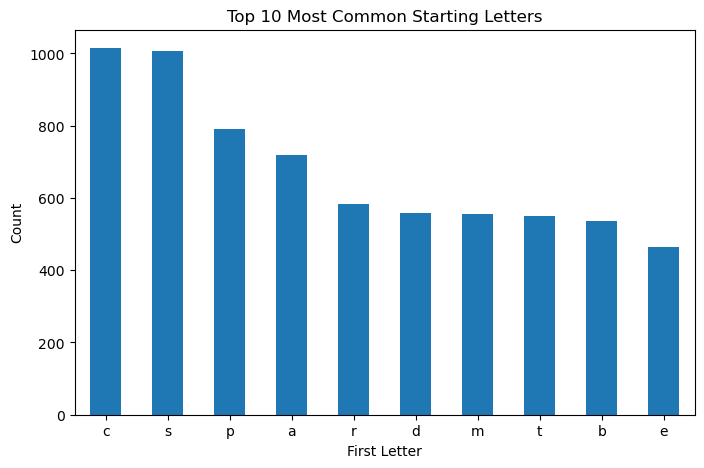

In [10]:
plt.figure(figsize=(8,5))
df['first_letter'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Starting Letters")
plt.xlabel("First Letter")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
word_list = df['word'].tolist()

def autocomplete(prefix, n=10):
    prefix = prefix.lower().strip()
    suggestions = [word for word in word_list if word.startswith(prefix)]
    return suggestions[:n]

In [12]:
print("Autocomplete for 'ap':", autocomplete("ap"))
print("Autocomplete for 'go':", autocomplete("go"))
print("Autocomplete for 'pro':", autocomplete("pro"))

Autocomplete for 'ap': ['application', 'april', 'applications', 'apr', 'apply', 'appropriate', 'approach', 'approved', 'apple', 'applied']
Autocomplete for 'go': ['go', 'good', 'government', 'going', 'got', 'god', 'gold', 'golf', 'google', 'goods']
Autocomplete for 'pro': ['products', 'product', 'program', 'project', 'profile', 'property', 'provide', 'process', 'provided', 'programs']


In [13]:
def autocorrect(word, n=5):
    word = word.lower().strip()
    suggestions = difflib.get_close_matches(word, word_list, n=n, cutoff=0.6)
    return suggestions

In [14]:
print("Autocorrect for 'recieve':", autocorrect("recieve"))
print("Autocorrect for 'govermant':", autocorrect("govermant"))
print("Autocorrect for 'langauge':", autocorrect("langauge"))

Autocorrect for 'recieve': ['receive', 'retrieve', 'receives', 'receiver', 'received']
Autocorrect for 'govermant': ['government', 'governments', 'german', 'governmental', 'vermont']
Autocorrect for 'langauge': ['language', 'languages', 'gauge', 'manage', 'engage']


In [15]:
test_prefixes = ["aut", "comp", "de", "inf"]
for prefix in test_prefixes:
    print(f"Suggestions for prefix '{prefix}': {autocomplete(prefix)}")

test_words = ["adress", "beleive", "enviroment", "teh"]
for word in test_words:
    print(f"Corrections for '{word}': {autocorrect(word)}")

Suggestions for prefix 'aut': ['author', 'auto', 'authority', 'authors', 'automotive', 'automatically', 'automatic', 'authorities', 'authorized', 'authentication']
Suggestions for prefix 'comp': ['company', 'computer', 'compare', 'complete', 'companies', 'computers', 'components', 'completed', 'complex', 'component']
Suggestions for prefix 'de': ['de', 'development', 'details', 'design', 'department', 'description', 'december', 'dec', 'delivery', 'deals']
Suggestions for prefix 'inf': ['information', 'info', 'informed', 'infrastructure', 'influence', 'infection', 'infant', 'inform', 'informational', 'inflation']
Corrections for 'adress': ['address', 'dress', 'addresses', 'addressed', 'madness']
Corrections for 'beleive': ['believe', 'believes', 'believed', 'eleven', 'belize']
Corrections for 'enviroment': ['environment', 'environments', 'environmental', 'enrollment', 'violent']
Corrections for 'teh': ['tech', 'th', 'te', 'eh', 'teeth']
